In [1]:
import numpy as np
import h5py
import json
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [2]:
h5_path = "../data/raw/TheCycloneImageDataset/Cyclone_Images.h5"

train_idx = np.load("../data/processed/train_idx.npy")
val_idx = np.load("../data/processed/val_idx.npy")
encoded_labels = np.load("../data/processed/encoded_labels.npy")

with open("../data/processed/category_mapping.json") as f:
    category_mapping = json.load(f)

num_classes = len(np.unique(encoded_labels))
print("Num classes:", num_classes)

Num classes: 6


In [3]:
def find_corrupt_indices(h5_path, indices, chunk=2000):
    corrupt = []
    indices_sorted = np.sort(indices)

    with h5py.File(h5_path, 'r') as f:
        images_ds = f['Images']
        for start in range(0, len(indices_sorted), chunk):
            batch_idx = indices_sorted[start:start+chunk]
            batch = images_ds[batch_idx].astype('float32')

            bad_mask = np.isnan(batch).any(axis=(1,2,3)) | np.isinf(batch).any(axis=(1,2,3))
            bad_indices = batch_idx[bad_mask]
            corrupt.extend(bad_indices.tolist())

    return np.array(corrupt)

corrupt_train = find_corrupt_indices(h5_path, train_idx)
corrupt_val = find_corrupt_indices(h5_path, val_idx)

train_idx_clean = np.array([i for i in train_idx if i not in set(corrupt_train)])
val_idx_clean = np.array([i for i in val_idx if i not in set(corrupt_val)])

print("Train:", len(train_idx), "->", len(train_idx_clean))
print("Val:", len(val_idx), "->", len(val_idx_clean))

Train: 14753 -> 14740
Val: 3161 -> 3157


In [4]:
SEQ_LEN = 5  # kitne consecutive images ek sequence me honge

def build_sequences(indices, labels, seq_len=SEQ_LEN, seed=42):
    rng = np.random.default_rng(seed)
    
    # Category ke hisaab se indices group karo
    category_groups = {}
    for idx in indices:
        cat = labels[idx]
        category_groups.setdefault(cat, []).append(idx)
    
    # Har group ke andar shuffle karo (pseudo-random "temporal" order simulate karne ke liye)
    for cat in category_groups:
        rng.shuffle(category_groups[cat])
    
    sequences = []
    sequence_targets = []
    
    for cat, idx_list in category_groups.items():
        n_sequences = len(idx_list) // (seq_len + 1)  # +1 kyunki last frame target hai
        for i in range(n_sequences):
            chunk = idx_list[i*(seq_len+1) : (i+1)*(seq_len+1)]
            seq_indices = chunk[:seq_len]
            target_idx = chunk[seq_len]
            sequences.append(seq_indices)
            sequence_targets.append(target_idx)
    
    return sequences, sequence_targets

train_sequences, train_targets = build_sequences(train_idx_clean, encoded_labels)
val_sequences, val_targets = build_sequences(val_idx_clean, encoded_labels)

print("Train sequences:", len(train_sequences))
print("Val sequences:", len(val_sequences))

Train sequences: 2455
Val sequences: 523


In [5]:
class ConvLSTMSequenceGenerator(tf.keras.utils.Sequence):
    def __init__(self, h5_path, sequences, targets, labels, batch_size=16, img_size=64, shuffle=True):
        self.h5_path = h5_path
        self.sequences = sequences
        self.targets = targets
        self.labels = labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.indices = np.arange(len(sequences))
        self.on_epoch_end()

    def __len__(self):
        return len(self.sequences) // self.batch_size

    def __getitem__(self, idx):
        batch_positions = self.indices[idx*self.batch_size : (idx+1)*self.batch_size]

        batch_seqs = [self.sequences[i] for i in batch_positions]
        batch_targets_idx = [self.targets[i] for i in batch_positions]

        # Saare unique indices ek saath fetch karo (efficient h5py access ke liye)
        all_idx_needed = sorted(set(idx for seq in batch_seqs for idx in seq) | set(batch_targets_idx))
        idx_map = {v: i for i, v in enumerate(all_idx_needed)}

        with h5py.File(self.h5_path, 'r') as f:
            fetched = f['Images'][all_idx_needed].astype('float32')

        # Resize aur normalize (chhota size use karenge speed ke liye)
        fetched_resized = tf.image.resize(fetched[..., :3], (self.img_size, self.img_size)).numpy() / 255.0

        X_batch = []
        y_batch = []
        for seq, target_idx in zip(batch_seqs, batch_targets_idx):
            seq_images = np.stack([fetched_resized[idx_map[i]] for i in seq])
            X_batch.append(seq_images)
            y_batch.append(self.labels[target_idx])

        return np.array(X_batch), np.array(y_batch)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [6]:
IMG_SIZE = 64  # ConvLSTM heavy hota hai, chhota size rakhna better hai

train_gen_lstm = ConvLSTMSequenceGenerator(
    h5_path, train_sequences, train_targets, encoded_labels,
    batch_size=16, img_size=IMG_SIZE, shuffle=True
)
val_gen_lstm = ConvLSTMSequenceGenerator(
    h5_path, val_sequences, val_targets, encoded_labels,
    batch_size=16, img_size=IMG_SIZE, shuffle=False
)

print("Batches per epoch (train):", len(train_gen_lstm))
print("Batches per epoch (val):", len(val_gen_lstm))

# Ek sample batch check karo
X_sample, y_sample = train_gen_lstm[0]
print("X shape:", X_sample.shape)   # (batch, seq_len, H, W, 3)
print("y shape:", y_sample.shape)

Batches per epoch (train): 153
Batches per epoch (val): 32


2026-09-02 02:34:35.661473: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-09-02 02:34:35.661715: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-09-02 02:34:35.662461: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-09-02 02:34:35.662866: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-02 02:34:35.662894: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


X shape: (16, 5, 64, 64, 3)
y shape: (16,)


In [7]:
model_convlstm = models.Sequential([
    layers.Input(shape=(5, IMG_SIZE, IMG_SIZE, 3)),

    layers.ConvLSTM2D(32, (3,3), activation='relu', padding='same', return_sequences=True),
    layers.BatchNormalization(),
    layers.MaxPooling3D((1,2,2)),

    layers.ConvLSTM2D(64, (3,3), activation='relu', padding='same', return_sequences=False),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model_convlstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 5, 64, 64, 32)  │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 64, 64, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 5, 32, 32, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 32, 32, 64)     │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,360,326 (9.00 MB)

 Trainable params: 2,360,134 (9.00 MB)

 Non-trainable params: 192 (768.00 B)

In [8]:
model_convlstm.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=6, restore_best_weights=True, verbose=1
)

In [10]:
history_convlstm = model_convlstm.fit(
    train_gen_lstm,
    validation_data=val_gen_lstm,
    epochs=10,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Epoch 1/10


/Users/chessinorbit/Desktop/CYCLONE-PREDICTION/venv/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2026-09-02 02:39:37.773093: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


153/153 ━━━━━━━━━━━━━━━━━━━━ 76s 458ms/step - accuracy: 0.3885 - loss: 8.7756 - val_accuracy: 0.1289 - val_loss: 4.9545 - learning_rate: 5.0000e-04
Epoch 2/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 70s 458ms/step - accuracy: 0.4743 - loss: 7.9630 - val_accuracy: 0.1621 - val_loss: 16.8884 - learning_rate: 5.0000e-04
Epoch 3/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 82s 535ms/step - accuracy: 0.5139 - loss: 7.0666 - val_accuracy: 0.1719 - val_loss: 19.1590 - learning_rate: 5.0000e-04
Epoch 4/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.5445 - loss: 6.1496
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
153/153 ━━━━━━━━━━━━━━━━━━━━ 89s 581ms/step - accuracy: 0.5445 - loss: 6.1496 - val_accuracy: 0.4629 - val_loss: 5.6687 - learning_rate: 5.0000e-04
Epoch 5/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 82s 534ms/step - accuracy: 0.5584 - loss: 5.9553 - val_accuracy: 0.6562 - val_loss: 2.6956 - learning_rate: 2.5000e-04
Epoch 6/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 87s 569ms/step - accu

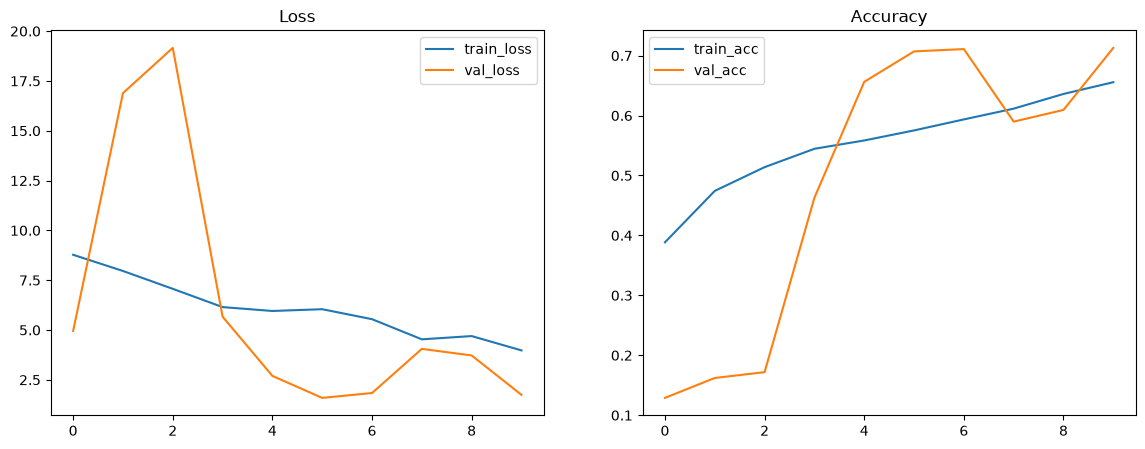

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_convlstm.history['loss'], label='train_loss')
axes[0].plot(history_convlstm.history['val_loss'], label='val_loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history_convlstm.history['accuracy'], label='train_acc')
axes[1].plot(history_convlstm.history['val_accuracy'], label='val_acc')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.show()

In [12]:
import os
os.makedirs("../models", exist_ok=True)
model_convlstm.save("../models/convlstm_pseudo_sequence.keras")
print("ConvLSTM model saved!")

ConvLSTM model saved!


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step


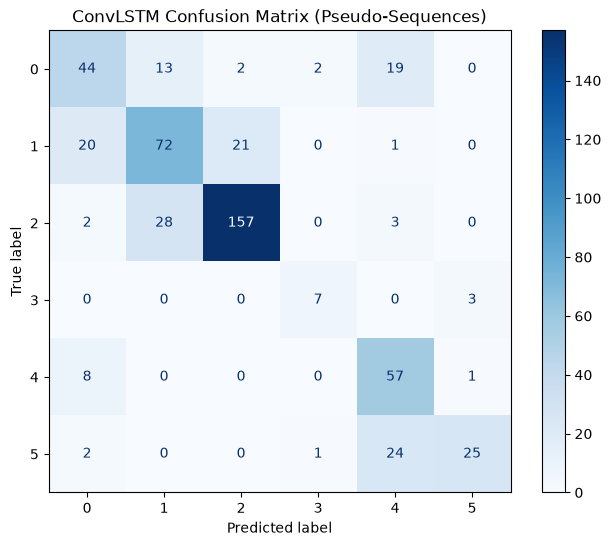

              precision    recall  f1-score   support

           0       0.58      0.55      0.56        80
           1       0.64      0.63      0.63       114
           2       0.87      0.83      0.85       190
           3       0.70      0.70      0.70        10
           4       0.55      0.86      0.67        66
           5       0.86      0.48      0.62        52

    accuracy                           0.71       512
   macro avg       0.70      0.68      0.67       512
weighted avg       0.73      0.71      0.71       512



In [13]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

val_preds = model_convlstm.predict(val_gen_lstm)
val_pred_labels = np.argmax(val_preds, axis=1)

val_true_labels = []
for i in range(len(val_gen_lstm)):
    batch_positions = val_gen_lstm.indices[i*val_gen_lstm.batch_size : (i+1)*val_gen_lstm.batch_size]
    for pos in batch_positions:
        target_idx = val_gen_lstm.targets[pos]
        val_true_labels.append(val_gen_lstm.labels[target_idx])
val_true_labels = np.array(val_true_labels)

cm = confusion_matrix(val_true_labels, val_pred_labels)

fig, ax = plt.subplots(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', ax=ax)
plt.title('ConvLSTM Confusion Matrix (Pseudo-Sequences)')
plt.show()

print(classification_report(val_true_labels, val_pred_labels))